In [2]:
import tensorflow as tf
from tensorflow import keras

In [21]:
import os
import numpy as np
from PIL import Image

# Paths
RAW_TRAIN_PATH = 'dataset/train'
PROCESSED_PATH = 'dataset/processed_train'
IMG_HEIGHT, IMG_WIDTH = 128, 128

os.makedirs(os.path.join(PROCESSED_PATH, 'images'), exist_ok=True)
os.makedirs(os.path.join(PROCESSED_PATH, 'masks'), exist_ok=True)

for folder in os.listdir(RAW_TRAIN_PATH):
    folder_path = os.path.join(RAW_TRAIN_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    images_dir = os.path.join(folder_path, 'images')
    masks_dir = os.path.join(folder_path, 'masks')
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_files:
        continue
    # Load and save the image
    img_path = os.path.join(images_dir, image_files[0])
    img = Image.open(img_path).convert('RGB').resize((IMG_WIDTH, IMG_HEIGHT), Image.LANCZOS)
    img.save(os.path.join(PROCESSED_PATH, 'images', f'{folder}.png'))
    # Merge all masks
    mask = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)
    for mask_file in os.listdir(masks_dir):
        if mask_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            mask_path = os.path.join(masks_dir, mask_file)
            m = Image.open(mask_path).convert('L').resize((IMG_WIDTH, IMG_HEIGHT), Image.LANCZOS)
            mask = np.maximum(mask, np.array(m, dtype=np.uint8))
    merged_mask = Image.fromarray(mask)
    merged_mask.save(os.path.join(PROCESSED_PATH, 'masks', f'{folder}.png'))

print("Processing complete. Images and merged masks saved in:", PROCESSED_PATH)


Processing complete. Images and merged masks saved in: dataset/processed_train


In [1]:
import numpy as np
import os
from PIL import Image

# Paths
PROCESSED_PATH = 'dataset/processed_train'
IMG_HEIGHT, IMG_WIDTH = 128, 128

# List all image files
image_files = sorted(os.listdir(os.path.join(PROCESSED_PATH, 'images')))
mask_files = sorted(os.listdir(os.path.join(PROCESSED_PATH, 'masks')))

# Initialize arrays
X_train = np.zeros((len(image_files), IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.uint8)
Y_train = np.zeros((len(mask_files), IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool_)

for i, file_name in enumerate(image_files):
    img_path = os.path.join(PROCESSED_PATH, 'images', file_name)
    mask_path = os.path.join(PROCESSED_PATH, 'masks', file_name)
    img = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(mask_path).convert('L'))
    X_train[i] = img
    Y_train[i, ..., 0] = mask > 0  # Binarize mask

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (670, 128, 128, 3)
Y_train shape: (670, 128, 128, 1)


In [9]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3

Contraction/Encoding Path

In [5]:
inputs = keras.layers.Input((IMG_WIDTH,IMG_HEIGHT,IMG_CHANNELS))
s = keras.layers.Lambda(lambda x: x/255)(inputs)

In [6]:
c1 = keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(s)
c1 = keras.layers.Dropout(0.1)(c1) #Randomly dropping some neurons
c1 = keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c1)
p1 = keras.layers.MaxPooling2D((2,2))(c1) #1st MaxPooling Layer


In [7]:
c2 = keras.layers.Conv2D(32,(3,3),activation='relu', kernel_initializer='he_normal',padding='same')(p1)
c2 = keras.layers.Dropout(0.1)(c2)
c2= keras.layers.Conv2D(32,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c2)
p2 = keras.layers.MaxPooling2D((2,2))(c2)


In [8]:
c3 = keras.layers.Conv2D(64,(3,3),activation='relu', kernel_initializer='he_normal',padding='same')(p2)
c3 = keras.layers.Dropout(0.2)(c3)
c3 = keras.layers.Conv2D(64,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c3)
p3 = keras.layers.MaxPooling2D((2,2))(c3)


In [9]:
c4 = keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(p3)
c4 = keras.layers.Dropout(0.2)(c4)
c4 = keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c4)
p4 = keras.layers.MaxPooling2D(pool_size=(2,2))(c4)

In [10]:
c5 = keras.layers.Conv2D(256,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(p4)
c5 = keras.layers.Dropout(0.2)(c5)
c5 = keras.layers.Conv2D(256,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c5)


Expansion/Decoding Path

In [11]:
u6 = keras.layers.Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(c5) #Upscaling
u6 = keras.layers.concatenate([u6,c4]) #Skip connection
c6 = keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(u6)
c6 = keras.layers.Dropout(0.2)(c6)
c6 = keras.layers.Conv2D(128,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c6)

In [12]:
u7 = keras.layers.Conv2DTranspose(64,(2,2),strides=(2,2),padding='same')(c6)
u7 = keras.layers.concatenate([u7,c3])
c7 = keras.layers.Conv2D(64,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(u7)
c7 = keras.layers.Dropout(0.2)(c7)
c7 = keras.layers.Conv2D(64,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c7)

In [13]:
u8 = keras.layers.Conv2DTranspose(32,(2,2),strides=(2,2),activation='relu',kernel_initializer='he_normal',padding='same')(c7)
u8 = keras.layers.concatenate([u8,c2])
c8 = keras.layers.Conv2D(32,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(u8)
c8 = keras.layers.Dropout(0.1)(c8)
c8 = keras.layers.Conv2D(32,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c8)

In [14]:
u9 = keras.layers.Conv2DTranspose(16,(2,2),strides=(2,2),activation='relu',kernel_initializer='he_normal',padding='same')(c8)
u9 = keras.layers.concatenate([u9,c1],axis=3)
c9 = keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(u9)
c9 = keras.layers.Dropout(0.1)(c9)
c9 = keras.layers.Conv2D(16,(3,3),activation='relu',kernel_initializer='he_normal',padding='same')(c9)

In [15]:
outputs = keras.layers.Conv2D(1,(1,1),activation='sigmoid')(c9)

In [16]:
model = keras.Model(inputs=[inputs],outputs=[outputs])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ lambda[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0] 

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
checkpointer = keras.callbacks.ModelCheckpoint('model-for-unet.h5', verbose=1, save_best_only=True)
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1),
             keras.callbacks.TensorBoard(log_dir='logs')]

In [19]:
results = model.fit(X_train, Y_train, validation_split=0.1, batch_size=4, epochs=50, callbacks=callbacks)

Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 29s 139ms/step - accuracy: 0.7794 - loss: 0.7494 - val_accuracy: 0.8895 - val_loss: 0.2702
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 22s 149ms/step - accuracy: 0.8949 - loss: 0.2465 - val_accuracy: 0.9199 - val_loss: 0.1807
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - accuracy: 0.9152 - loss: 0.1915 - val_accuracy: 0.9172 - val_loss: 0.2067
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 161ms/step - accuracy: 0.9165 - loss: 0.1837 - val_accuracy: 0.9255 - val_loss: 0.1614
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 163ms/step - accuracy: 0.9186 - loss: 0.1791 - val_accuracy: 0.9204 - val_loss: 0.1812
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9182 - loss: 0.1783 - val_accuracy: 0.9252 - val_loss: 0.1713
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 24s 157ms/step - accuracy: 0.9184 - loss: 0.1744 - val_accuracy: 0.9300 - val_loss: 0.1504
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9207 - loss: 0

In [20]:
model.save('model-for-unet.h5')


In [3]:
#Load the model
model = keras.models.load_model('model-for-unet.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


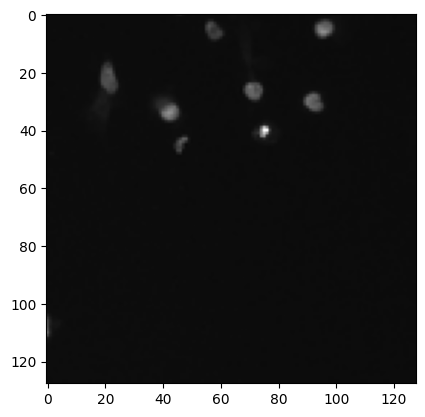

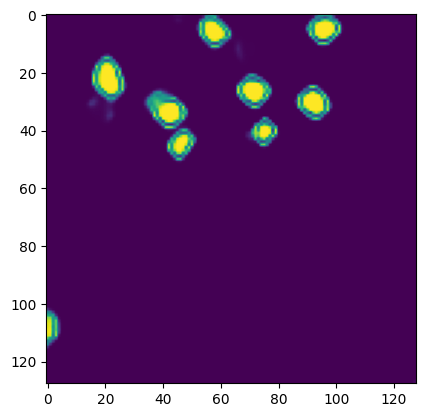

In [11]:
#usage example:
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
IMG_PATH = r"D:\CellNucleiSeg\dataset\test\0e132f71c8b4875c3c2dd7a22997468a3e842b46aa9bd47cf7b0e8b7d63f0925\images\0e132f71c8b4875c3c2dd7a22997468a3e842b46aa9bd47cf7b0e8b7d63f0925.png"
img = Image.open(IMG_PATH).convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT), Image.LANCZOS)
img_array = np.array(img)
img_array = img_array.reshape((1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
pred = model.predict(img_array, verbose=1)
plt.imshow(img_array[0].astype(np.uint8))
plt.show()
plt.imshow(pred[0].squeeze())
